# 🎬 Système de recommandation de films — MovieLens

**Objectif du projet** : construire et comparer trois approches classiques de
systèmes de recommandation (content-based, collaborative filtering, hybride),
sur le jeu de données [MovieLens (ml-latest-small)](https://grouplens.org/datasets/movielens/),
qui contient ~100 000 notes attribuées par 610 utilisateurs à 9 742 films.

Ce notebook explique chaque concept en langage simple avant de l'implémenter,
de façon à ce que la démarche soit compréhensible même sans bagage poussé en
machine learning.

**Plan** :
1. Exploration des données (EDA)
2. Approche *content-based* (similarité de contenu)
3. Approche *collaborative filtering* (factorisation matricielle SVD)
4. Approche hybride
5. Comparaison et conclusion


In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 60)

from recommender import (
    load_data,
    ContentBasedRecommender,
    CollaborativeRecommender,
    HybridRecommender,
)


## 1. Exploration des données (EDA)

On charge les deux fichiers principaux : `movies.csv` (catalogue de films
avec leurs genres) et `ratings.csv` (chaque ligne = un utilisateur a noté un
film, de 0.5 à 5 étoiles).


In [2]:
movies, ratings = load_data()

print(f"Nombre de films      : {len(movies):,}")
print(f"Nombre de notes      : {len(ratings):,}")
print(f"Nombre d'utilisateurs: {ratings['userId'].nunique():,}")
print(f"Densité de la matrice user x film : {len(ratings) / (ratings.userId.nunique() * movies.movieId.nunique()):.2%}")


Nombre de films      : 9,742
Nombre de notes      : 100,836
Nombre d'utilisateurs: 610
Densité de la matrice user x film : 1.70%


La densité ci-dessus (très faible, en général <2%) illustre **pourquoi** le
collaborative filtering est un problème difficile : la grande majorité des
combinaisons (utilisateur, film) n'a jamais été observée. C'est précisément
ce que la factorisation matricielle (SVD) va essayer de combler.


In [3]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


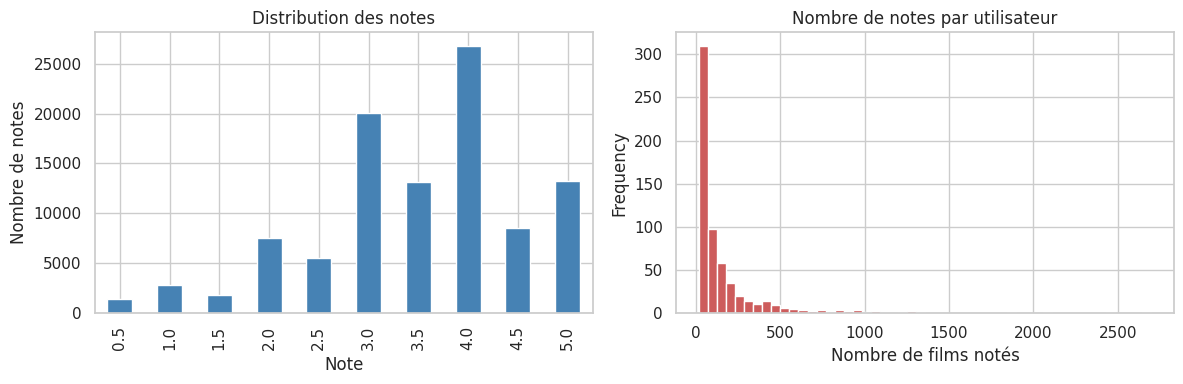

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Distribution des notes")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Nombre de notes")

ratings.groupby('userId').size().plot(kind='hist', bins=50, ax=axes[1], color='indianred')
axes[1].set_title("Nombre de notes par utilisateur")
axes[1].set_xlabel("Nombre de films notés")

plt.tight_layout()
plt.show()


On observe que les notes sont biaisées vers le haut (3, 4 et 5 étoiles
dominent — les gens notent surtout ce qu'ils ont aimé), et que certains
utilisateurs très actifs ont noté des centaines de films alors que la
majorité en a noté une vingtaine (le minimum imposé par la construction du
dataset).


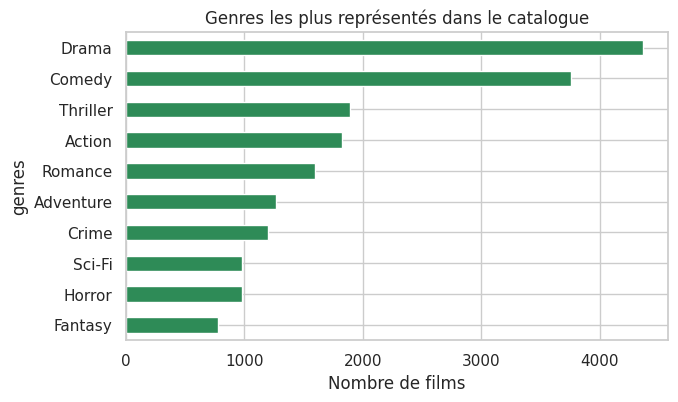

In [6]:
top_genres = movies['genres'].str.split('|').explode().value_counts().head(10)
top_genres.plot(kind='barh', figsize=(7, 4), color='seagreen')
plt.title("Genres les plus représentés dans le catalogue")
plt.xlabel("Nombre de films")
plt.gca().invert_yaxis()
plt.show()


## 2. Approche Content-Based

**Principe** : on recommande des films qui *ressemblent* à un film donné, en
se basant uniquement sur leurs caractéristiques (ici, les genres — on
pourrait aussi utiliser un résumé, des mots-clés, le réalisateur, etc.).

**Comment ça marche concrètement ?**

1. On transforme la liste de genres de chaque film (`"Comedy|Romance"`) en un
   vecteur numérique via **TF-IDF**. Un genre rare (ex: *Film-Noir*) reçoit un
   poids plus fort qu'un genre très courant (ex: *Drama*), car il est plus
   discriminant pour repérer une vraie ressemblance.
2. On calcule la **similarité cosinus** entre chaque paire de vecteurs : un
   score entre 0 (rien en commun) et 1 (vecteurs identiques). Géométriquement,
   c'est l'angle entre deux vecteurs — deux films avec exactement les mêmes
   genres "pointent" dans la même direction.


In [7]:
content_model = ContentBasedRecommender(movies)
print("Matrice TF-IDF :", content_model.tfidf_matrix.shape, "(films x genres uniques)")


Matrice TF-IDF : (9742, 24) (films x genres uniques)


In [8]:
content_model.recommend("Toy Story (1995)", top_n=10)


,movieId,title,genres,score_similarite
0,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
4,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0
5,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,1.0
6,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.0
7,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.0
8,91355,Asterix and the Vikings (Astérix et les Vikings) (2006),Adventure|Animation|Children|Comedy|Fantasy,1.0
9,103755,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,1.0


**Limite à garder en tête** : cette approche ne regarde QUE les genres. Elle
recommandera par exemple beaucoup de films d'animation familiaux après *Toy
Story*, ce qui est cohérent, mais elle est incapable de capter des
ressemblances plus subtiles (ambiance, réalisateur, qualité perçue) qu'un
humain repérerait. C'est la limite structurelle du content-based : il
reproduit ce qui est déjà décrit dans les métadonnées, ni plus ni moins.


## 3. Approche Collaborative Filtering (SVD)

**Principe** : on ignore complètement le contenu des films. On regarde
uniquement qui a aimé quoi, et on cherche des utilisateurs aux goûts
similaires aux tiens pour te recommander ce qu'ils ont aimé.

**Comment ça marche concrètement ?**

On peut imaginer une immense matrice où les lignes sont les utilisateurs, les
colonnes les films, et chaque case la note donnée (la plupart des cases sont
vides). La **factorisation matricielle (SVD)** consiste à "résumer" chaque
utilisateur et chaque film par un petit vecteur de nombres (des "facteurs
latents" — ici 50). On peut voir ces facteurs comme des axes de goût abstraits
(pas directement nommables, contrairement aux genres) que l'algorithme
découvre lui-même à partir des données. En recombinant le vecteur d'un
utilisateur et celui d'un film, le modèle **prédit** la note que cet
utilisateur donnerait à ce film, même s'il ne l'a jamais vu.

On utilise la librairie [Surprise](http://surpriselib.com/), qui implémente
cet algorithme avec une API simple : `.fit()` pour entraîner, `.predict()`
pour prédire une note.


In [9]:
collab_model = CollaborativeRecommender(ratings, movies)

rmse = collab_model.evaluate()
print(f"RMSE sur le jeu de test : {rmse:.3f}")
print("(RMSE = écart moyen entre la note prédite et la note réelle, sur une échelle de 0.5 à 5 — plus c'est bas, mieux c'est)")


RMSE sur le jeu de test : 0.877
(RMSE = écart moyen entre la note prédite et la note réelle, sur une échelle de 0.5 à 5 — plus c'est bas, mieux c'est)


**Comparaison avec une baseline naïve** : pour juger si 50 facteurs latents
apportent vraiment quelque chose, on compare au modèle le plus simple
possible — prédire systématiquement la note moyenne globale, sans aucune
personnalisation.


In [10]:
from sklearn.metrics import mean_squared_error

testset_df = pd.DataFrame(collab_model.testset, columns=["userId", "movieId", "rating"])
moyenne_globale = ratings["rating"].mean()
rmse_baseline = mean_squared_error(testset_df["rating"], [moyenne_globale] * len(testset_df)) ** 0.5

print(f"RMSE baseline (note moyenne globale) : {rmse_baseline:.3f}")
print(f"RMSE modèle SVD                      : {rmse:.3f}")
print(f"Amélioration : {(1 - rmse/rmse_baseline):.1%}")


RMSE baseline (note moyenne globale) : 1.045
RMSE modèle SVD                      : 0.877
Amélioration : 16.0%


Le modèle SVD réduit nettement l'erreur par rapport à la baseline : la
personnalisation apporte une vraie valeur, ce n'est pas juste un effet de
hasard. C'est exactement le genre de comparaison qu'il faut toujours
présenter — un score seul (RMSE = 0.87) ne veut rien dire sans un point de
référence.


In [11]:
collab_model.recommend(user_id=1, top_n=10)


,movieId,title,genres,note_predite
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,5.00
1,741,Ghost in the Shell (Kôkaku kidôtai) (1995),Animation|Sci-Fi,5.00
2,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,5.00
3,1204,Lawrence of Arabia (1962),Adventure|Drama|War,5.00
4,2160,Rosemary's Baby (1968),Drama|Horror|Thriller,5.00
5,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,5.00
6,3275,"Boondock Saints, The (2000)",Action|Crime|Drama|Thriller,5.00
7,38061,Kiss Kiss Bang Bang (2005),Comedy|Crime|Mystery|Thriller,5.00
8,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",Comedy|Romance,4.99
9,48516,"Departed, The (2006)",Crime|Drama|Thriller,4.98


## 4. Approche Hybride

**Principe** : on prend un large pool de films bien notés par le modèle
collaboratif pour un utilisateur, puis on les re-classe en fonction de leur
ressemblance de contenu avec les films que cet utilisateur a déjà aimés
(notes ≥ 4). Le score final est une moyenne pondérée :

`score_hybride = α × score_collaboratif + (1 − α) × score_contenu`

Avec α = 0.6 par défaut, on donne un peu plus de poids au signal
collaboratif (généralement plus puissant) tout en laissant le contenu
"recentrer" les recommandations vers les goûts thématiques connus de
l'utilisateur.


In [12]:
hybrid_model = HybridRecommender(content_model, collab_model)
hybrid_model.recommend(user_id=1, top_n=10)


,movieId,title,genres,note_predite,score_contenu,score_hybride
0,6016,City of God (Cidade de Deus) (2002),Action|Adventure|Crime|Drama|Thriller,4.96,0.333677,0.728138
1,1215,Army of Darkness (1993),Action|Adventure|Comedy|Fantasy|Horror,4.91,0.300853,0.708341
2,3275,"Boondock Saints, The (2000)",Action|Crime|Drama|Thriller,5.00,0.270791,0.708316
3,6350,Laputa: Castle in the Sky (Tenkû no shiro Rapyuta) (1986),Action|Adventure|Animation|Children|Fantasy|Sci-Fi,4.88,0.308572,0.707429
4,908,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller,4.96,0.260177,0.698737
5,1223,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi,4.93,0.269227,0.698357
6,1249,"Femme Nikita, La (Nikita) (1990)",Action|Crime|Romance|Thriller,4.93,0.244750,0.688567
7,1204,Lawrence of Arabia (1962),Adventure|Drama|War,5.00,0.212836,0.685134
8,4011,Snatch (2000),Comedy|Crime|Thriller,4.97,0.222808,0.685123
9,68954,Up (2009),Adventure|Animation|Children|Drama,4.93,0.231963,0.683452


## 5. Comparaison et conclusion

Récapitulons les recommandations des trois approches, pour le même
utilisateur, côte à côte.


In [13]:
user_id = 1
print("Films que l'utilisateur", user_id, "a le mieux notés :")
display(
    ratings[ratings.userId == user_id]
    .merge(movies, on="movieId")
    .sort_values("rating", ascending=False)
    [["title", "rating"]]
    .head(5)
)

print("\nTop 5 — Collaboratif :")
display(collab_model.recommend(user_id, top_n=5)[["title", "note_predite"]])

print("\nTop 5 — Hybride :")
display(hybrid_model.recommend(user_id, top_n=5)[["title", "score_hybride"]])


Films que l'utilisateur 1 a le mieux notés :


,title,rating
3,Seven (a.k.a. Se7en) (1995),5.0
4,"Usual Suspects, The (1995)",5.0
6,Bottle Rocket (1996),5.0
13,Dumb & Dumber (Dumb and Dumber) (1994),5.0
11,Billy Madison (1995),5.0



Top 5 — Collaboratif :


,title,note_predite
0,"Shawshank Redemption, The (1994)",5.0
1,Ghost in the Shell (Kôkaku kidôtai) (1995),5.0
2,Cinema Paradiso (Nuovo cinema Paradiso) (1989),5.0
3,Lawrence of Arabia (1962),5.0
4,Rosemary's Baby (1968),5.0



Top 5 — Hybride :


,title,score_hybride
0,City of God (Cidade de Deus) (2002),0.728138
1,Army of Darkness (1993),0.708341
2,"Boondock Saints, The (2000)",0.708316
3,Laputa: Castle in the Sky (Tenkû no shiro Rapyuta) (1986),0.707429
4,North by Northwest (1959),0.698737


### Ce qu'on retient

- Le **content-based** est simple, explicable et fonctionne même sans aucune
  donnée d'interaction (idéal pour un nouveau film), mais reste enfermé dans
  les genres déclarés.
- Le **collaboratif** capture des goûts beaucoup plus fins et surprenants
  (un RMSE nettement meilleur qu'une baseline naïve le prouve), mais ne
  fonctionne pas pour un nouvel utilisateur ou un nouveau film sans historique
  (le classique "problème du cold start").
- L'**hybride** atténue les deux faiblesses en combinant les deux signaux —
  c'est l'approche utilisée en production par la plupart des plateformes de
  streaming réelles.

### Pour aller plus loin (pistes d'amélioration)

- Utiliser des métadonnées plus riches en content-based (résumé du film via
  TF-IDF sur le texte, acteurs, réalisateur) plutôt que les seuls genres.
- Tester un autre algorithme collaboratif (ex: factorisation non-négative,
  ou un modèle de deep learning avec des embeddings).
- Évaluer aussi en *precision@k* / *recall@k* (est-ce que les films
  réellement aimés par l'utilisateur apparaissent dans le top-k recommandé ?),
  une métrique plus proche de l'usage réel qu'un simple RMSE.
- Gérer explicitement le cold start (nouvel utilisateur sans note : démarrer
  par des recommandations basées sur la popularité ou un questionnaire de
  goûts initial).
